In [26]:
# Производим импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

### Загрузка данных

In [2]:
# Загружаем датасет
df = pd.read_csv('synthetic_regression.csv')

In [3]:
# Разбеваем датасет на массив призноков 'X' и целевую переменную 'y'
X = df.drop(columns='target').values
y = df['target'].values

In [4]:
# Отделяем тестувую выборку (20%)
X_temp, X_test, y_temp, y_test  = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# Разбиваем оставшиеся данные для обучения (80%) и для валидации (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

In [6]:
# Выводим информацию о данных
print(f"Train size: {X_train.shape[0]}, Val size: {X_val.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Train shape:     X = {X_train.shape}, y = {y_train.shape}")
print(f"Validation shape: X = {X_val.shape}, y = {y_val.shape}")
print(f"Test shape:      X = {X_test.shape}, y = {y_test.shape}") 

Train size: 128, Val size: 32, Test size: 40
Train shape:     X = (128, 40), y = (128,)
Validation shape: X = (32, 40), y = (32,)
Test shape:      X = (40, 40), y = (40,)


In [7]:
# Импортируем истинные коэфффициенты
true_coefs_df = pd.read_csv('true_coefs.csv')
true_coefs = true_coefs_df['coef'].values

In [8]:
print("Форма true_coefs:", true_coefs.shape)
# Выводим истинные коэффициенты
print("Истинные коэффициенты (true_coefs):")
print(true_coefs) 

Форма true_coefs: (40,)
Истинные коэффициенты (true_coefs):
[ 0.          0.          0.          0.          0.         92.46228178
  0.         39.13780934  0.         62.49224698  0.          0.
  0.          0.          0.         78.39252791  0.          3.18567625
  0.          0.          0.          0.          0.          0.
  0.          0.         39.75918693 51.92800824  0.         77.98186756
  0.          0.          0.         46.93029964  0.          0.
  0.          0.          0.         85.79519454]


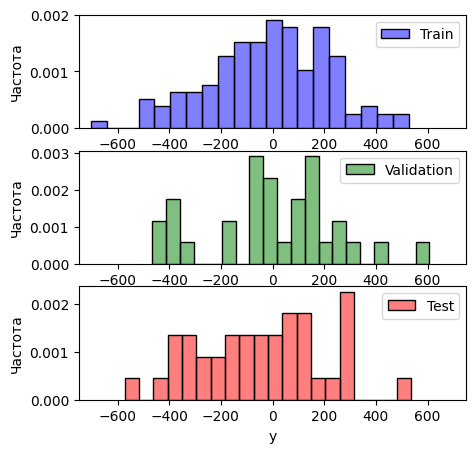

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(5, 5))

sns.histplot(
    y_train, color='blue', label='Train', bins=20, alpha=0.5, stat='density', ax=axes[0]
)
axes[0].legend()
axes[0].set_xlabel('y')
axes[0].set_ylabel('Частота')
axes[0].set_xlim(-750, 750)

sns.histplot(
    y_val, color='green', label='Validation', bins=20, alpha=0.5, stat='density', ax=axes[1]
)
axes[1].legend()
axes[1].set_xlabel('y')
axes[1].set_ylabel('Частота')
axes[1].set_xlim(-750, 750)

sns.histplot(
    y_test, color='red', label='Test', bins=20, alpha=0.5, stat='density', ax=axes[2]
)
axes[2].legend()
axes[2].set_xlabel('y')
axes[2].set_ylabel('Частота')
axes[2].set_xlim(-750, 750)

plt.show()

### Линейная Регрессия без регуляризации

In [10]:
# Обучаем модель LinearRegression
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
# Предсказываем целевую метрику на валидационных данных
y_pred_val = lr_model.predict(X_val)

In [12]:
# Оцениваем качество модели lr_model
mse_lr_model = mean_squared_error(y_val, y_pred_val)
r2_lr_model = r2_score(y_val, y_pred_val)

print(f"LinearRegression → MSE: {mse_lr_model:.3f}, R2: {r2_lr_model:.3f}")

LinearRegression → MSE: 20064.504, R2: 0.672


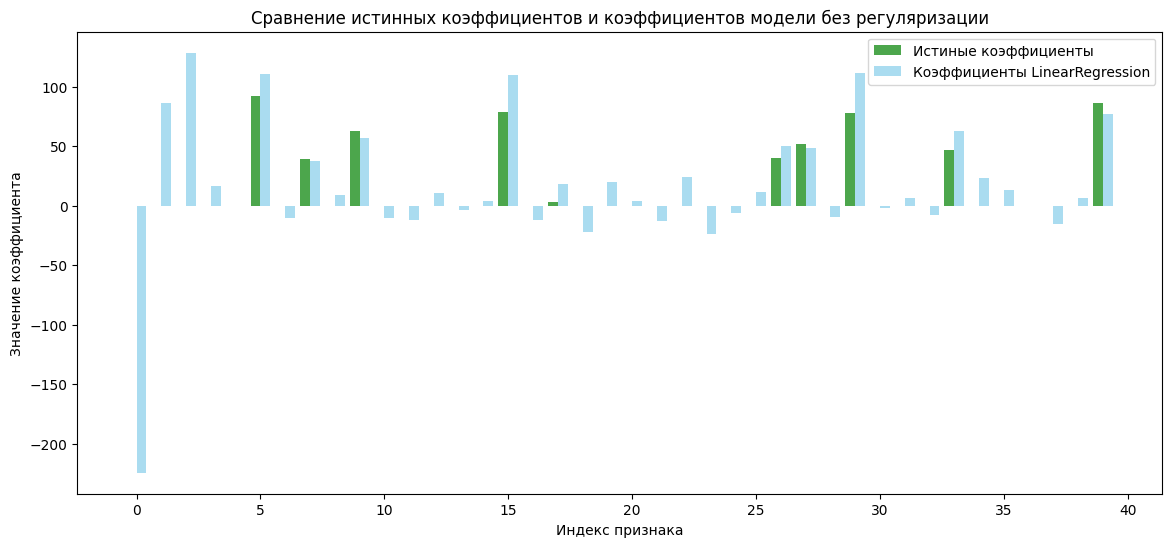

In [ ]:
indices = np.arange(len(true_coefs))
width = 0.4

plt.figure(figsize=(14, 6))


plt.bar(
    indices - width / 2,
    true_coefs,
    width=width,
    label='Истиные коэффициенты',
    color='green',
    alpha=0.7
)

plt.bar(
    indices + width / 2,
    lr_model.coef_,
    width=width,
    label='Коэффициенты LinearRegression',
    color='skyblue',
    alpha=0.7    
)

plt.xlabel('Индекс признака')  
plt.ylabel('Значение коэффициента')  
plt.title('Сравнение истинных коэффициентов и коэффициентов модели без регуляризации') 
plt.legend() 
plt.show()

### Линейная Регрессия с L2-регуляризацией(Ridge) 

In [19]:
# Обучаем модель Ridge
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(X_train, y_train)

,alpha,10.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [20]:
# Предсказываем целевую метрику на валидационных данных
y_pred_ridge = ridge_model.predict(X_val)

In [21]:
# Оцениваем качество модели lr_model
mse_ridge = mean_squared_error(y_val, y_pred_ridge)
r2_ridge = r2_score(y_val, y_pred_ridge)

print(f"Val MSE: {mse_ridge:.3f}, R2: {r2_ridge:.3f}")

Val MSE: 14896.072, R2: 0.756


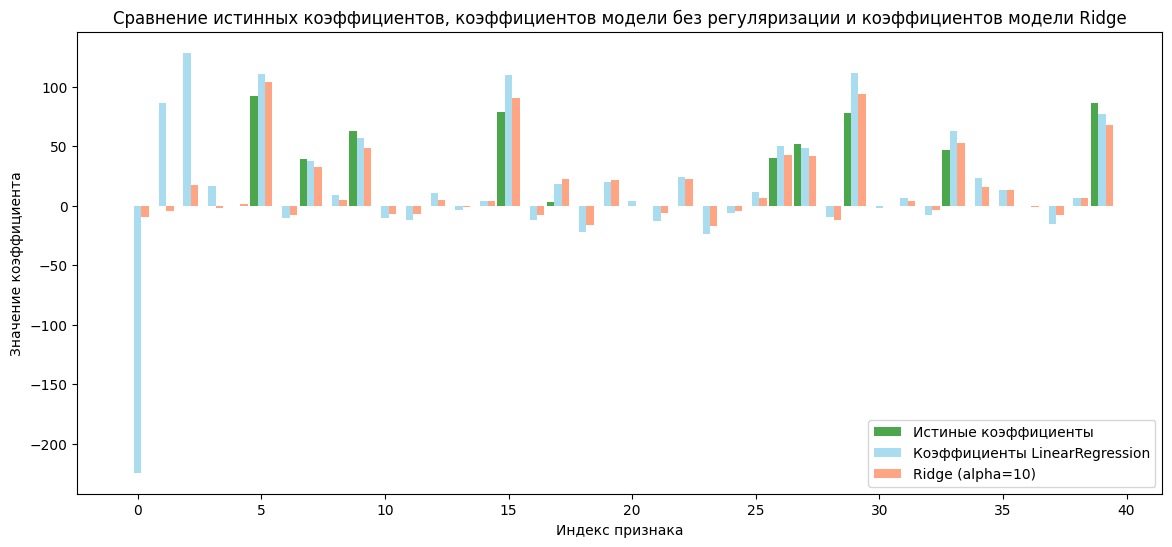

In [23]:
indices = np.arange(len(true_coefs))
width = 0.3

plt.figure(figsize=(14, 6))

# Истинные коэффициенты
plt.bar(
    indices - width,
    true_coefs,
    width=width,
    label='Истиные коэффициенты',
    color='green',
    alpha=0.7
)

# Коэффициенты LinearRegression (без регуляризации)
plt.bar(
    indices,
    lr_model.coef_,
    width=width,
    label='Коэффициенты LinearRegression',
    color='skyblue',
    alpha=0.7    
)

# Коэффициенты Ridge (с alpha=10)
plt.bar(
    indices + width,
    ridge_model.coef_,
    width=width,
    label='Ridge (alpha=10)',
    color='coral',
    alpha=0.7
)

plt.xlabel('Индекс признака')  
plt.ylabel('Значение коэффициента')  
plt.title('Сравнение истинных коэффициентов, коэффициентов модели без регуляризации и коэффициентов модели Ridge') 
plt.legend() 
plt.show()

### Линейная Регрессия с L1-регуляризацией(Lasso) 

In [30]:
# Обучаем модель Lasso
lasso_model = Lasso(alpha=10.0)
lasso_model.fit(X_train, y_train)

,alpha,10.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [31]:
# Предсказываем целевую метрику на валидационных данных
y_pred_lasso = lasso_model.predict(X_val)

In [32]:
# Оцениваем качество модели lasso_model
mse_lasso = mean_squared_error(y_val, y_pred_lasso)
r2_lasso = r2_score(y_val, y_pred_lasso)

print(f"Val MSE: {mse_lasso:.3f}, R2: {r2_lasso:.3f}")

Val MSE: 13166.774, R2: 0.784


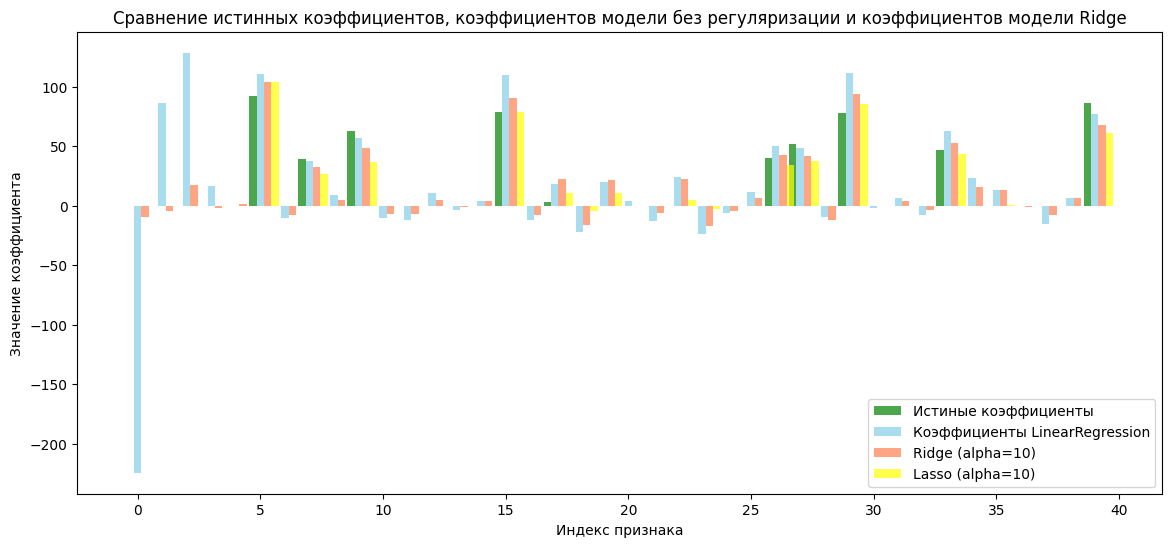

In [33]:
indices = np.arange(len(true_coefs))
width = 0.3

plt.figure(figsize=(14, 6))

# Истинные коэффициенты
plt.bar(
    indices - width,
    true_coefs,
    width=width,
    label='Истиные коэффициенты',
    color='green',
    alpha=0.7
)

# Коэффициенты LinearRegression (без регуляризации)
plt.bar(
    indices,
    lr_model.coef_,
    width=width,
    label='Коэффициенты LinearRegression',
    color='skyblue',
    alpha=0.7    
)

# Коэффициенты Ridge (с alpha=10)
plt.bar(
    indices + width,
    ridge_model.coef_,
    width=width,
    label='Ridge (alpha=10)',
    color='coral',
    alpha=0.7
)

# Коэффициенты Lasso (с alpha=10)
plt.bar(
    indices + 2 * width,
    lasso_model.coef_,
    width=width,
    label='Lasso (alpha=10)',
    color='yellow',
    alpha=0.7
)

plt.xlabel('Индекс признака')  
plt.ylabel('Значение коэффициента')  
plt.title('Сравнение истинных коэффициентов, коэффициентов модели без регуляризации и коэффициентов модели Ridge') 
plt.legend() 
plt.show()

### Финальная оценка на тестовой выборке

In [36]:
X_full = np.vstack([X_train, X_val])
y_full = np.hstack([y_train, y_val])

In [37]:
# Предсказание и оценка лучшей модели Lasso при alpha=10
y_pred_test = lasso_model.predict(X_full)

# Оцениваем качество модели
mse_test = mean_squared_error(y_full, y_pred_test)
r2_test = r2_score(y_full, y_pred_test)

print(f"Test MSE: {mse_test:.3f}, R2: {r2_test:.3f}") 

Test MSE: 11050.145, R2: 0.798
